# Landmine HSI + EMI Comparison — Complete Notebook (LOCAL / Jupyter / GPU)
### RIT-DIRS Site 2 · Hyperspectral (VNIR) vs EM61-Lite EMI · depth & material resolved

Runs end-to-end on your laptop. GPU via **CuPy** (optional; auto-falls back to NumPy).
Produces: the depth-resolved HSI detectability diagnostics **and** the HSI-vs-EMI comparison
by burial depth and ferrous/non-ferrous class.

**Data needed in `DATA_DIR`:**
- `elm_corrected_vnir` (+`.hdr`) — VNIR cube
- `EO_properties_and_Locations_field2.csv` — targets (depth, ferrous, lon/lat)
- `Spectral_Signatures_of_Targets/*.sig`
- `emi/` — the EM61-Lite Excel line files (lineA/lineB `_excel.xlsx`, etc.)

> ⚠️ macOS note: files starting with `._` are metadata stubs — ignore them. Use the real `.xlsx`.
> ⚠️ Verify the dataset license (CC-BY-4.0) attribution before publishing.


## 1 · Imports + GPU backend

In [1]:
!pip install -q spectral rasterio scikit-learn matplotlib numpy scipy pandas openpyxl tqdm
import os, glob, time, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
import spectral
from numpy.linalg import inv, norm
from scipy.ndimage import uniform_filter, maximum_filter, binary_dilation
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve

USE_GPU=True; xp=np; gpu_ok=False
if USE_GPU:
    try:
        import cupy as cp; cp.zeros(1)+1; xp=cp; gpu_ok=True
        print("GPU:", cp.cuda.runtime.getDeviceProperties(0)['name'].decode())
    except Exception as e:
        print("CPU (NumPy). CuPy not used:", str(e)[:80])
def to_xp(a): return xp.asarray(a)
def to_np(a): return cp.asnumpy(a) if gpu_ok else np.asarray(a)
plt.rcParams['figure.dpi']=110

C:\Users\sabah\.conda\envs\mines\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


GPU: NVIDIA GeForce RTX 5070 Laptop GPU


## 2 · Paths & constants (EDIT `DATA_DIR`)

In [2]:
DATA_DIR = r"D:/landmine_hsi"        # <-- EDIT

CUBE_HDR = os.path.join(DATA_DIR,"elm_corrected_vnir.hdr")
EO_CSV   = os.path.join(DATA_DIR,"EO_properties_and_Locations_field2.csv")
SIG_DIR  = os.path.join(DATA_DIR,"Spectral_Signatures_of_Targets")
EMI_DIR  = os.path.join(DATA_DIR,"Metal Detector EM61 Lite Data")  # <-- your EMI folder
FIG_DIR  = os.path.join(DATA_DIR,"figures"); os.makedirs(FIG_DIR, exist_ok=True)

# georeferencing (from .hdr map info)
X_TIE,Y_TIE=-96.85744848,36.35322567; DX,DY=1.0e-07,8.0e-08
SAMPLES,LINES,BANDS=6631,3123,272
GOOD_BAND_MAX_NM=900; COV_REG=1e-3; SIG_SCALE=100.0
def lonlat_to_pixel(lon,lat): return (Y_TIE-lat)/DY,(lon-X_TIE)/DX
print("config set")

config set


## 3 · Open cube (memory-mapped)

In [3]:
img=spectral.open_image(CUBE_HDR); mm=img.open_memmap(writable=False)
WL=np.array([float(w) for w in img.metadata['wavelength']])
band_ok=WL<=GOOD_BAND_MAX_NM; WL_use=WL[band_ok]
print("cube",mm.shape,"| analysis bands",int(band_ok.sum()))

cube (3123, 6631, 272) | analysis bands 226


## 4 · Targets → pixels + lon/lat + burial/material

In [4]:
eo = pd.read_csv(EO_CSV, encoding='utf-8-sig')
# strip + de-dup columns (CSV has two 'ID' columns)
_c=[c.strip() for c in eo.columns]; _s={}; _dd=[]
for c in _c:
    if c in _s: _s[c]+=1; _dd.append(f"{c}.{_s[c]}")
    else: _s[c]=0; _dd.append(c)
eo.columns=_dd

# --- classify every row: real target / control hole / blank ------------------
# The CSV has 150 rows but only ~131 are real targets: 8 are CONTROL HOLES
# (empty dug reference points, no ordnance) and 11 are BLANK/placeholder rows.
# Including holes/blanks as "targets" inflated the counts and corrupted results.
def row_kind(item):
    s=str(item).strip()
    if s=='' or s.lower()=='nan': return 'blank'
    if 'hole' in s.lower():       return 'control_hole'
    return 'target'
eo['kind']=eo['Item'].apply(row_kind)

def burial_class(d):
    # NOTE: 6 cm shallow/deep cut is a modeling choice; prefer depth_cm regression.
    try: d=float(d)
    except: return None
    return 'surface' if d==0 else ('shallow' if d<=6 else 'deep')
def material_class(fe):
    s=str(fe).strip(); return 'metal' if s=='1' else ('non_metal' if s=='0' else None)
def emi_class(item, ferrous, cls):
    s=str(item).lower(); c=str(cls).lower(); fe=str(ferrous).strip()
    if fe=='1': return 'conductive'
    if any(k in s for k in ['alum','copper','brass','steel','can','pipe bomb','copper pipe',
                            'phone','htc','huawei','cooker','tipman','shell','drill','mk ']): return 'conductive'
    if '3d print' in c or any(k in s for k in
            ['pvc','tnt','plastic','pmn','pfm','ts-50','vs-1.6','vpma','ozm','propane']): return 'inert'
    if fe=='0': return 'inert'
    return 'unknown'
def num_depth(d):
    try: return float(d)
    except: return np.nan

targets=[]; holes=[]
for _,r in eo.iterrows():
    if pd.isna(r['Longitude']) or pd.isna(r['Latitude']): continue
    lon,lat=float(r['Longitude']),float(r['Latitude'])
    row,col=lonlat_to_pixel(lon,lat)
    if not(0<=row<LINES and 0<=col<SAMPLES): continue
    rec=dict(id=str(r['ID']).strip(), item=str(r['Item']).strip(),
             lon=lon, lat=lat, depth=r['Depth'], depth_cm=num_depth(r['Depth']),
             row=int(round(row)), col=int(round(col)))
    if r['kind']=='control_hole':
        holes.append(rec)                                   # kept aside as control
    elif r['kind']=='target':
        b=burial_class(r['Depth'])
        if b is None: continue
        rec.update(burial=b, material=material_class(r['Ferrous (1) or NF (0)']),
                   emi_class=emi_class(r['Item'], r['Ferrous (1) or NF (0)'], r['Class']))
        targets.append(rec)
    # blanks ignored

from collections import Counter
print("=== TARGET SET (cleaned) ===")
print(f"real targets used  : {len(targets)}   (excl. {int((eo.kind=='control_hole').sum())} holes, "
      f"{int((eo.kind=='blank').sum())} blanks)")
print("burial  :", dict(Counter(t['burial']   for t in targets)))
print("material:", dict(Counter(t['material']  for t in targets)))
print("emi_cls :", dict(Counter(t['emi_class'] for t in targets)))
print(f"control holes kept aside: {len(holes)}")

=== TARGET SET (cleaned) ===
real targets used  : 131   (excl. 8 holes, 11 blanks)
burial  : {'deep': 30, 'shallow': 70, 'surface': 31}
material: {'non_metal': 41, 'metal': 86, None: 4}
emi_cls : {'conductive': 104, 'inert': 25, 'unknown': 2}
control holes kept aside: 8


## 5 · Load field crop + high-pass (local background)

In [5]:
MARGIN=60
r0=max(0,min(t['row'] for t in targets)-MARGIN); r1=min(LINES,max(t['row'] for t in targets)+MARGIN)
c0=max(0,min(t['col'] for t in targets)-MARGIN); c1=min(SAMPLES,max(t['col'] for t in targets)+MARGIN)
field=np.array(mm[r0:r1,c0:c1,:],dtype=np.float32,order="C"); H,W=field.shape[:2]  # np.array forces a WRITABLE copy
for t in targets: t['r']=t['row']-r0; t['c']=t['col']-c0
print("field",field.shape,"writable=",field.flags.writeable,"(~%.1f GB)"%(field.nbytes/1e9))

def rgb_of(cube):
    idx=[np.argmin(abs(WL-x)) for x in (640,550,470)]; comp=cube[:,:,idx].astype(np.float32)
    lo,hi=np.percentile(comp,[2,98]); return np.clip((comp-lo)/(hi-lo+1e-9),0,1)
# Build RGB from the RAW field BEFORE the in-place high-pass repurposes it.
RGB=rgb_of(field)

# ---- local-background high-pass, IN PLACE (no second full-cube copy) ----
# `field` is overwritten with high-passed values; only a small band-sized buffer is allocated.
t0=time.time()
HP=field                                   # same array; overwrite band-by-band
_tmp=np.empty((H,W),dtype=np.float32)
for b in range(BANDS):
    uniform_filter(field[:,:,b],31,mode='reflect',output=_tmp)
    HP[:,:,b]=field[:,:,b]-_tmp
del _tmp
print("high-pass (in place) %.1fs"%(time.time()-t0))

field (1337, 2787, 272) writable= True (~4.1 GB)
high-pass (in place) 30.7s


## 6 · Per-target HSI anomaly score (RX on local-background data)

In [6]:
HPb=HP[:,:,band_ok]
allm=np.zeros((H,W),bool)
for t in targets: allm[max(0,t['r']-3):t['r']+4,max(0,t['c']-3):t['c']+4]=True
bgm=~binary_dilation(allm,iterations=8)
BG=HPb[bgm].reshape(-1,int(band_ok.sum()))
rng=np.random.default_rng(0)
if BG.shape[0]>200000: BG=BG[rng.choice(BG.shape[0],200000,replace=False)]
mu=to_xp(BG.mean(0)); C=xp.cov(to_xp(BG).T)+COV_REG*xp.eye(BG.shape[1]); Ci=xp.linalg.inv(C)
def rx_patch(patch):
    xm=to_xp(patch)-mu; return to_np(xp.einsum('ij,ij->i',xm@Ci,xm))
for t in targets:
    p=HP[max(0,t['r']-3):t['r']+4,max(0,t['c']-3):t['c']+4][:,:,band_ok].reshape(-1,int(band_ok.sum()))
    t['hsi_score']=float(np.nanmean(rx_patch(p))) if len(p) else np.nan
# background anomaly 95th pct for reference
bgvals=rx_patch(BG[rng.choice(BG.shape[0],min(20000,BG.shape[0]),replace=False)])
hsi_thr=np.percentile(bgvals,95)
print("HSI anomaly by burial:")
import numpy as _np
for b in ['surface','shallow','deep']:
    v=[t['hsi_score'] for t in targets if t['burial']==b]
    print(f"  {b:8s} mean={_np.nanmean(v):.2f}  %>bg95={_np.mean(_np.array(v)>hsi_thr):.1%}")

HSI anomaly by burial:
  surface  mean=242.94  %>bg95=9.7%
  shallow  mean=235.94  %>bg95=4.3%
  deep     mean=242.69  %>bg95=0.0%


## 7 · Load EM61-Lite EMI survey lines

USING COMBINED FILE: Copy of shift_combined_file.xlsx | signal Channel1_new | rows 2042

total EMI points: 2042 | signal range 0.0..8362.8


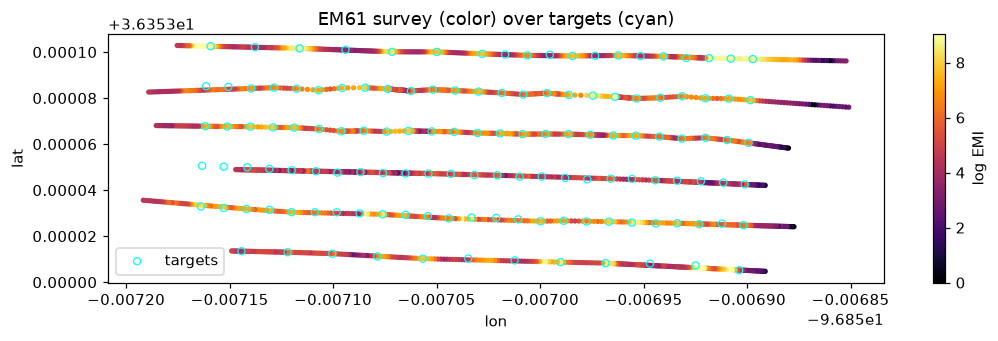

In [7]:
# ---- EMI loader (robust): finds the folder, prefers the combined leveled file ----
def find_emi_dir(base, hint):
    if os.path.isdir(hint) and glob.glob(os.path.join(hint,"**","*.xlsx"),recursive=True):
        return hint
    # search anywhere under DATA_DIR for a folder containing EM61 xlsx files
    for root,_,files in os.walk(base):
        low=os.path.basename(root).lower()
        if ('em61' in low or 'metal detector' in low) and any(f.lower().endswith('.xlsx') for f in files):
            print("auto-located EMI folder:",root); return root
    # last resort: any folder that has a combined/shift xlsx
    for f in glob.glob(os.path.join(base,"**","*combined*.xlsx"),recursive=True):
        return os.path.dirname(f)
    return hint

def load_emi(folder):
    folder=find_emi_dir(DATA_DIR, folder)
    files=[f for f in glob.glob(os.path.join(folder,"**","*.xlsx"),recursive=True)
           if not os.path.basename(f).startswith("._")]
    if not files:
        raise FileNotFoundError(f"No .xlsx found under {folder}. Set EMI_DIR to the folder "
                                f"that contains the EM61 files (e.g. the combined file).")
    def read_one(f):
        df=pd.read_excel(f)
        df.columns=[str(c).strip() for c in df.columns]
        ch_new=[c for c in df.columns if c.lower().startswith('channel') and c.lower().endswith('_new')]
        ch_raw=[c for c in df.columns if c.lower().startswith('channel') and not c.lower().endswith('_new')]
        if not (ch_new or ch_raw): return None
        chcol=ch_new[0] if ch_new else ch_raw[0]          # leveled Channel1_new preferred
        loncol=next((c for c in df.columns if c.lower() in ('longitude','lon')), None)
        latcol=next((c for c in df.columns if c.lower() in ('latitude','lat')), None)
        if loncol is None or df[loncol].isna().all(): return None
        s=pd.DataFrame({'lon':df[loncol],'lat':df[latcol],'emi':df[chcol].abs()}).dropna()
        s['signal']=chcol; return s

    # 1) combined/leveled file wins
    combined=[f for f in files if 'combined' in os.path.basename(f).lower()]
    if combined:
        s=read_one(combined[0])
        if s is not None and len(s):
            print("USING COMBINED FILE:",os.path.basename(combined[0]),
                  "| signal",s['signal'].iloc[0],"| rows",len(s))
            return s.drop(columns='signal')

    # 2) else stitch best variant per line; prefer 'Bfinal' over 'B'
    import re
    lines={}
    for f in files:
        if 'combined' in os.path.basename(f).lower(): continue
        m=re.search(r'line([A-Za-z0-9]+?)(?:_|\.)', os.path.basename(f))
        if m: lines.setdefault(m.group(1).lower(),[]).append(f)
    if 'bfinal' in lines and 'b' in lines:
        del lines['b']; print("note: using 'lineBfinal' as reprocessed replacement for line B")
    frames=[]
    for L,fs in sorted(lines.items()):
        for suf in ('_shift','_interpolated','_excel'):
            pick=next((f for f in fs if suf in os.path.basename(f)), None)
            if pick:
                s=read_one(pick)
                if s is not None:
                    print(f"  line {L}: {os.path.basename(pick)} signal={s['signal'].iloc[0]} rows={len(s)}")
                    frames.append(s.drop(columns='signal')); break
    if not frames:
        raise FileNotFoundError("Found .xlsx files but none had coordinates. "
                                "Use the '_shift'/'_interpolated' or combined file (the '_excel' ones lack lon/lat).")
    return pd.concat(frames,ignore_index=True)

emi=load_emi(EMI_DIR)
print("\ntotal EMI points:",len(emi),"| signal range %.1f..%.1f"%(emi['emi'].min(),emi['emi'].max()))
plt.figure(figsize=(10,3.2))
sc=plt.scatter(emi['lon'],emi['lat'],c=np.log1p(emi['emi']),s=6,cmap='inferno')
plt.scatter([t['lon'] for t in targets],[t['lat'] for t in targets],
            s=22,facecolors='none',edgecolors='cyan',linewidths=0.8,label='targets')
plt.colorbar(sc,label='log EMI'); plt.legend(); plt.title('EM61 survey (color) over targets (cyan)')
plt.xlabel('lon'); plt.ylabel('lat'); plt.tight_layout(); plt.show()

## 8 · Match EMI to targets (real lon/lat, meters)

The `_shift` files carry real WGS84 `Longitude`/`Latitude` and the leveled `Channel1_new` response.
We match each target to the strongest EMI reading within `MATCH_RADIUS_M`. **The survey lines only
cover a strip of the field**, so targets with no nearby reading are marked *not covered*, and the
comparison is restricted to covered targets for fairness.

In [8]:
def meters(lon1,lat1,lon2,lat2,lat0=36.353):
    kx=np.cos(np.radians(lat0))*111320.0; ky=110900.0
    return np.hypot((lon1-lon2)*kx,(lat1-lat2)*ky)

MATCH_RADIUS_M = 1.0     # EM61 footprint; targets farther than this are 'not surveyed'
el,ea,ev=emi['lon'].values,emi['lat'].values,emi['emi'].values
for t in targets:
    d=meters(el,ea,t['lon'],t['lat']); near=d<=MATCH_RADIUS_M
    t['emi_score']=float(np.nanmax(ev[near])) if near.any() else np.nan
    t['emi_covered']=bool(near.any())

emi_thr=np.nanpercentile(ev,90)   # detection threshold on EMI response
for t in targets:
    t['emi_detected']=bool(np.isfinite(t.get('emi_score',np.nan)) and t['emi_score']>emi_thr)

covered=[t for t in targets if t['emi_covered']]
print(f"IMPORTANT: the EMI survey lines cover only part of the field.")
print(f"targets within {MATCH_RADIUS_M} m of an EMI reading: {len(covered)}/{len(targets)}")
from collections import Counter
print("covered by burial:",dict(Counter(t['burial'] for t in covered)))
print("covered by material:",dict(Counter(t['material'] for t in covered)))
print("\n=> All HSI-vs-EMI comparison below is restricted to these covered targets (fair comparison).")

IMPORTANT: the EMI survey lines cover only part of the field.
targets within 1.0 m of an EMI reading: 130/131
covered by burial: {'deep': 30, 'shallow': 69, 'surface': 31}
covered by material: {'non_metal': 40, 'metal': 86, None: 4}

=> All HSI-vs-EMI comparison below is restricted to these covered targets (fair comparison).


## 9 · HSI vs EMI — comparison table & figures

=== detection RATE by burial (fraction of covered targets detected) ===
         hsi_detected  emi_detected
burial                             
surface          0.10          0.26
shallow          0.04          0.52
deep             0.00          0.53

=== EMI detection rate by material x burial ===
material  metal  non_metal
burial                    
surface    0.26       0.14
shallow    0.48       0.64
deep       0.63       0.36

=== mean EMI response by material (ferrous should dominate) ===
material
metal        2391.4
non_metal    2352.7
Name: emi, dtype: float64


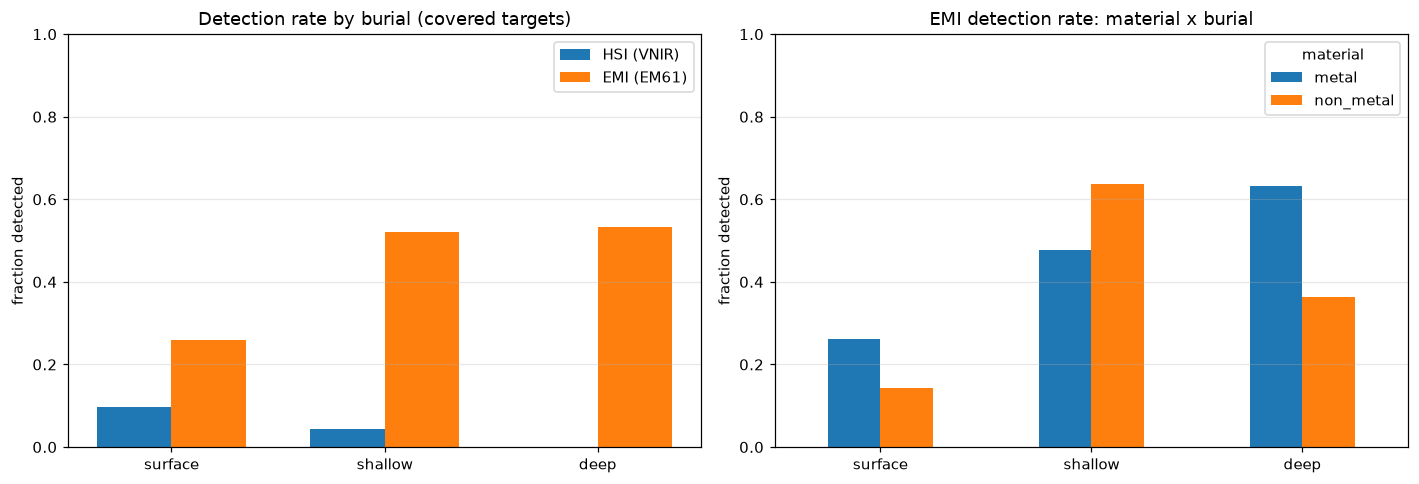


saved fig_hsi_vs_emi.png and hsi_vs_emi_per_target.csv (130 covered targets)


In [9]:
cov=[t for t in targets if t['emi_covered']]
df=pd.DataFrame([dict(id=t['id'],burial=t['burial'],material=t['material'],
    hsi=t.get('hsi_score',np.nan),emi=t.get('emi_score',np.nan),
    emi_detected=bool(t['emi_detected'])) for t in cov])

# HSI detection using its own background-95th threshold (from cell 6)
df['hsi_detected']=df['hsi']>hsi_thr

def norm(x):
    x=x.astype(float); lo,hi=np.nanpercentile(x,5),np.nanpercentile(x,95)
    return np.clip((x-lo)/(hi-lo+1e-9),0,1)
df['hsi_n']=norm(df['hsi']); df['emi_n']=norm(df['emi'])
order=['surface','shallow','deep']

print("=== detection RATE by burial (fraction of covered targets detected) ===")
print(df.groupby('burial')[['hsi_detected','emi_detected']].mean().reindex(order).round(2))
print("\n=== EMI detection rate by material x burial ===")
print(df.groupby(['burial','material'])['emi_detected'].mean().unstack().reindex(order).round(2))
print("\n=== mean EMI response by material (ferrous should dominate) ===")
print(df.groupby('material')['emi'].mean().round(1))

fig,ax=plt.subplots(1,2,figsize=(13,4.5))
g=df.groupby('burial')[['hsi_detected','emi_detected']].mean().reindex(order)
x=np.arange(3); w=0.35
ax[0].bar(x-w/2,g['hsi_detected'],w,label='HSI (VNIR)'); ax[0].bar(x+w/2,g['emi_detected'],w,label='EMI (EM61)')
ax[0].set_xticks(x); ax[0].set_xticklabels(order); ax[0].set_ylim(0,1)
ax[0].set_ylabel('fraction detected'); ax[0].set_title('Detection rate by burial (covered targets)')
ax[0].legend(); ax[0].grid(axis='y',alpha=.3)
det=df.groupby(['burial','material'])['emi_detected'].mean().unstack().reindex(order)
det.plot(kind='bar',ax=ax[1],rot=0); ax[1].set_ylim(0,1); ax[1].set_ylabel('fraction detected')
ax[1].set_xlabel('')
ax[1].set_title('EMI detection rate: material x burial'); ax[1].grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'fig_hsi_vs_emi.png'),bbox_inches='tight'); plt.show()
df.to_csv(os.path.join(FIG_DIR,'hsi_vs_emi_per_target.csv'),index=False)
print(f"\nsaved fig_hsi_vs_emi.png and hsi_vs_emi_per_target.csv ({len(df)} covered targets)")

## 9b · EMI separability — the honest, strong numbers

Two questions EMI can actually answer here: (1) does it separate *targets from background soil*?
(2) does it separate *conductive from inert* targets? The first is the strong result; the second,
on this field, is weak — many "inert" ERW still contain metal fuzes/fragments, so EMI flags
*presence*, not *material*. Report both honestly.

In [10]:
# --- self-heal: ensure emi_class exists on targets (in case cell 4 wasn't re-run) ---
if targets and 'emi_class' not in targets[0]:
    _eo=pd.read_csv(EO_CSV, encoding='utf-8-sig')
    _c=[c.strip() for c in _eo.columns]; _s={}; _dd=[]
    for c in _c:
        if c in _s: _s[c]+=1; _dd.append(f"{c}.{_s[c]}")
        else: _s[c]=0; _dd.append(c)
    _eo.columns=_dd
    def _emi_class(item, ferrous, cls):
        s=str(item).lower(); c=str(cls).lower(); fe=str(ferrous).strip()
        if fe=='1': return 'conductive'
        if any(k in s for k in ['alum','copper','brass','steel','can','pipe bomb','copper pipe',
                                'phone','htc','huawei','cooker','tipman','shell','drill','mk ']): return 'conductive'
        if 'control hole' in c or '3d print' in c or any(k in s for k in
                ['hole','pvc','tnt','plastic','pmn','pfm','ts-50','vs-1.6','vpma','ozm','propane']): return 'inert'
        if fe=='0': return 'inert'
        return 'unknown'
    _lut={ str(r['ID']).strip(): _emi_class(r['Item'],r['Ferrous (1) or NF (0)'],r['Class'])
           for _,r in _eo.iterrows() if pd.notna(r['ID']) }
    for t in targets: t['emi_class']=_lut.get(str(t['id']).strip(),'unknown')
    print("added emi_class to",len(targets),"targets")

from sklearn.metrics import roc_auc_score
cov=[t for t in targets if t.get('emi_covered')]
cdf=pd.DataFrame([dict(burial=t['burial'],emi_class=t['emi_class'],
                       emi=t['emi_score'],det=t['emi_detected']) for t in cov])

print("=== EMI detection rate by EMI-responsiveness class ===")
print(cdf.groupby('emi_class')['det'].mean().round(2).to_string())
print("\n=== EMI detection: emi_class x burial ===")
print(cdf.groupby(['burial','emi_class'])['det'].mean().unstack().reindex(['surface','shallow','deep']).round(2).to_string())

# target-vs-background AUC (EMI's strongest result)
tl=np.array([t['lon'] for t in cov]); ta=np.array([t['lat'] for t in cov])
def mind(lo,la): return np.min(np.hypot((tl-lo)*90000,(ta-la)*111000))
bg=np.array([e for lo,la,e in zip(emi['lon'],emi['lat'],emi['emi']) if mind(lo,la)>2.0])
def auc(sub):
    y=np.r_[np.ones(len(sub)),np.zeros(len(bg))]; s=np.r_[np.asarray(sub),bg]
    ok=np.isfinite(s); return roc_auc_score(y[ok],s[ok])
allv=cdf['emi'].dropna().values
print(f"\nEMI target-vs-background AUC (all targets): {auc(allv):.3f}   <- EMI localizes buried objects")
for g in ['conductive','inert']:
    v=cdf[cdf.emi_class==g]['emi'].dropna().values
    if len(v): print(f"  {g:10s} vs background AUC: {auc(v):.3f}")
print("\nInterpretation: high AUC for BOTH classes => EMI detects 'something buried here',")
print("but does not cleanly separate material type on this field.")

=== EMI detection rate by EMI-responsiveness class ===
emi_class
conductive    0.48
inert         0.33
unknown       1.00

=== EMI detection: emi_class x burial ===
emi_class  conductive  inert  unknown
burial                               
surface          0.25   0.17      1.0
shallow          0.51   0.54      1.0
deep             0.64   0.00      NaN

EMI target-vs-background AUC (all targets): 0.996   <- EMI localizes buried objects
  conductive vs background AUC: 0.996
  inert      vs background AUC: 0.993

Interpretation: high AUC for BOTH classes => EMI detects 'something buried here',
but does not cleanly separate material type on this field.


## 9d · Continuous depth view + surface-vs-buried (honest framing)

Replaces the arbitrary shallow/deep split. Shows EMI (and HSI, if available) against
**measured depth in cm**, and a single grounded categorical split: surface (0 cm) vs.
buried (>0 cm). Saves per-target EMI/depth so the report can be rebuilt on real data.

EMI vs depth:  Pearson r=0.188 (p=0.0324)  Spearman rho=0.144
HSI vs depth:  Pearson r=-0.064 (p=0.47)

SURFACE (0 cm) vs BURIED (>0 cm):
  buried   n= 99  EMI det=0.53  mean EMI=2601  HSI det=0.08
  surface  n= 31  EMI det=0.26  mean EMI=1622  HSI det=0.16


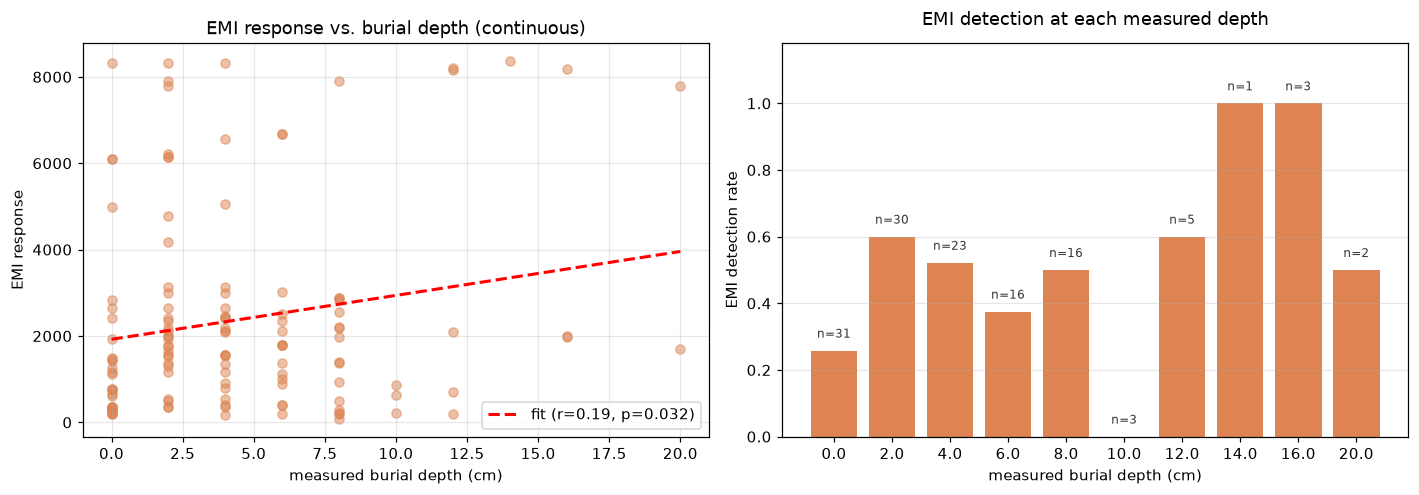


saved emi_depth_continuous.png and emi_per_target_scores.csv


In [11]:
import pandas as pd   # re-bind guard
from scipy.stats import pearsonr, spearmanr

cov=[t for t in targets if t.get('emi_covered')]
rows=[]
for t in cov:
    rows.append(dict(id=t['id'], depth_cm=t.get('depth_cm', np.nan),
                     surface=(t.get('depth_cm',np.nan)==0),
                     material=t.get('material'), emi_class=t.get('emi_class'),
                     emi=t.get('emi_score', np.nan),
                     emi_det=bool(t.get('emi_detected', False)),
                     hsi=t.get('hsi_score', np.nan)))
d=pd.DataFrame(rows)
dd=d.dropna(subset=['depth_cm','emi'])

# --- continuous: EMI vs depth ---
r_e,p_e=pearsonr(dd['depth_cm'], dd['emi'])
print(f"EMI vs depth:  Pearson r={r_e:.3f} (p={p_e:.3g})  "
      f"Spearman rho={spearmanr(dd['depth_cm'],dd['emi']).correlation:.3f}")
if dd['hsi'].notna().sum()>2:
    hh=dd.dropna(subset=['hsi'])
    r_h,p_h=pearsonr(hh['depth_cm'], hh['hsi'])
    print(f"HSI vs depth:  Pearson r={r_h:.3f} (p={p_h:.3g})")

# --- surface vs buried (the one grounded split) ---
print("\nSURFACE (0 cm) vs BURIED (>0 cm):")
for grp,sub in d.groupby('surface'):
    lab='surface' if grp else 'buried'
    print(f"  {lab:8s} n={len(sub):3d}  EMI det={sub['emi_det'].mean():.2f}  "
          f"mean EMI={sub['emi'].mean():.0f}"
          + (f"  HSI det={ (sub['hsi']>np.nanpercentile(d['hsi'],90)).mean():.2f}" if sub['hsi'].notna().any() else ""))

# --- figure: EMI vs depth (continuous) + detection rate at each measured depth ---
fig,ax=plt.subplots(1,2,figsize=(13,4.6))
ax[0].scatter(dd['depth_cm'], dd['emi'], alpha=0.5, color='#dd8452')
z=np.polyfit(dd['depth_cm'], dd['emi'], 1); xs=np.linspace(0,dd['depth_cm'].max(),50)
ax[0].plot(xs, np.polyval(z,xs), 'r--', lw=2, label=f'fit (r={r_e:.2f}, p={p_e:.2g})')
ax[0].set_xlabel('measured burial depth (cm)'); ax[0].set_ylabel('EMI response')
ax[0].set_title('EMI response vs. burial depth (continuous)'); ax[0].legend(); ax[0].grid(alpha=.3)
bd=dd.groupby('depth_cm')['emi_det'].agg(['mean','count'])
ax[1].bar(bd.index.astype(str), bd['mean'], color='#dd8452')
ax[1].set_ylim(0,1.18)   # headroom so n-labels don't collide with the title
for x,(m,n) in enumerate(zip(bd['mean'],bd['count'])):
    ax[1].text(x, min(m+0.03,1.08), f'n={n}', ha='center', va='bottom', fontsize=8, color='#333')
ax[1].set_xlabel('measured burial depth (cm)'); ax[1].set_ylabel('EMI detection rate')
ax[1].set_title('EMI detection at each measured depth', pad=12); ax[1].grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'emi_depth_continuous.png'),dpi=150,bbox_inches='tight'); plt.show()

d.to_csv(os.path.join(FIG_DIR,'emi_per_target_scores.csv'), index=False)
print("\nsaved emi_depth_continuous.png and emi_per_target_scores.csv")

## 9c · Control-hole test — does EMI flag ordnance or just disturbance?

The 8 control holes contain **no ordnance** (empty dug reference points). If EMI responds to them
as strongly as to real buried targets, the EMI signal reflects **soil disturbance**, not metal —
a direct test of what an EMI detection actually means on this field.

control holes  (n=8): mean EMI=5204  det.rate=0.88
buried targets (n=99): mean EMI=2601  det.rate=0.53
Mann-Whitney holes vs buried: p=0.006
=> empty holes respond ~as strongly as buried ordnance => EMI flags DISTURBANCE, not material


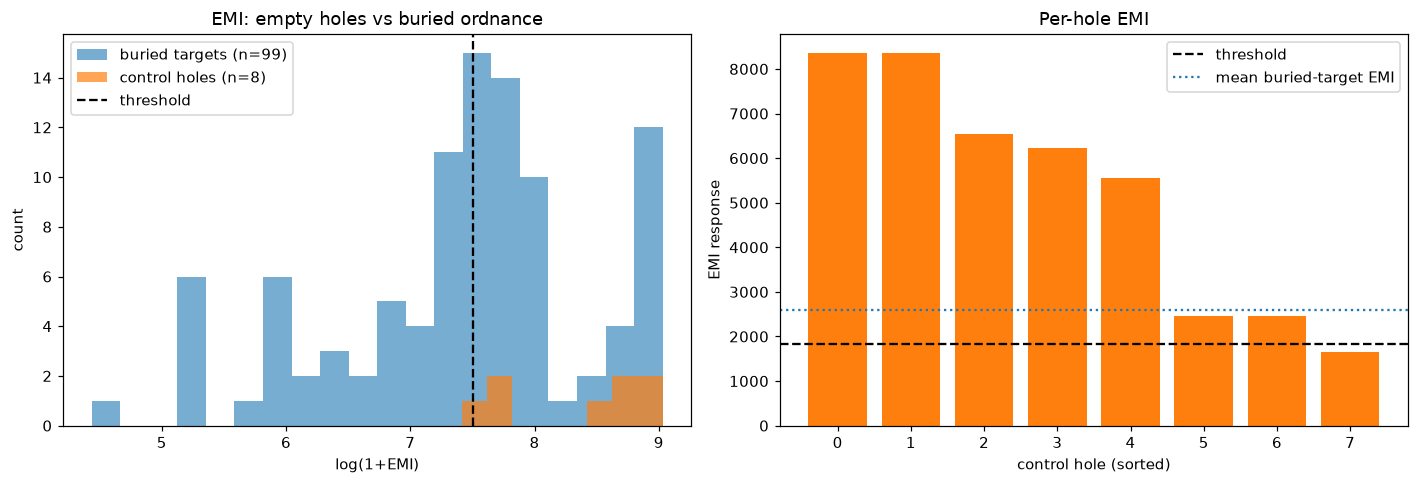

In [12]:
from scipy import stats
el,ea,ev=emi['lon'].values,emi['lat'].values,emi['emi'].values
def _m(a,b,c,d,lat0=36.353): return np.hypot((a-c)*np.cos(np.radians(lat0))*111320,(b-d)*110900)
def emi_at(lon,lat,R=1.0):
    d=_m(el,ea,lon,lat); n=d<=R; return float(np.nanmax(ev[n])) if n.any() else np.nan
emi_thr=np.nanpercentile(ev,90)

hole_emi=np.array([emi_at(h['lon'],h['lat']) for h in holes]); hole_emi=hole_emi[np.isfinite(hole_emi)]
buried=[t for t in targets if t['burial'] in ('shallow','deep')]
buried_emi=np.array([emi_at(t['lon'],t['lat']) for t in buried]); buried_emi=buried_emi[np.isfinite(buried_emi)]

print(f"control holes  (n={len(hole_emi)}): mean EMI={hole_emi.mean():.0f}  det.rate={np.mean(hole_emi>emi_thr):.2f}")
print(f"buried targets (n={len(buried_emi)}): mean EMI={buried_emi.mean():.0f}  det.rate={np.mean(buried_emi>emi_thr):.2f}")
u,p=stats.mannwhitneyu(hole_emi,buried_emi,alternative='two-sided')
print(f"Mann-Whitney holes vs buried: p={p:.3f}")
print("=> empty holes respond ~as strongly as buried ordnance => EMI flags DISTURBANCE, not material"
      if hole_emi.mean()>=buried_emi.mean() else "=> buried targets exceed holes => response is ordnance-driven")

fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
a1.hist(np.log1p(buried_emi),bins=20,alpha=0.6,label=f'buried targets (n={len(buried_emi)})')
a1.hist(np.log1p(hole_emi),bins=8,alpha=0.7,label=f'control holes (n={len(hole_emi)})')
a1.axvline(np.log1p(emi_thr),color='k',ls='--',label='threshold'); a1.legend()
a1.set_xlabel('log(1+EMI)'); a1.set_ylabel('count'); a1.set_title('EMI: empty holes vs buried ordnance')
a2.bar(range(len(hole_emi)),np.sort(hole_emi)[::-1],color='tab:orange')
a2.axhline(emi_thr,color='k',ls='--',label='threshold')
a2.axhline(buried_emi.mean(),color='tab:blue',ls=':',label='mean buried-target EMI')
a2.set_xlabel('control hole (sorted)'); a2.set_ylabel('EMI response'); a2.set_title('Per-hole EMI'); a2.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'fig_control_holes.png'),bbox_inches='tight'); plt.show()

## 10 · Notes
- **EMI coordinate frame is the key gotcha.** EM61 `_excel` files are often local/UTM meters. If
  cell 7 prints "PROJECTED", cell 8 aligns by normalized field extent, which assumes the EMI survey
  and the target set cover the *same* footprint. Verify by eye; for publication, do a proper
  reprojection (e.g. `pyproj`) from the EMI CRS to WGS84 lon/lat and match in meters.
- `_interpolated` files (gridded) can replace the raw line files for a smoother EMI surface;
  point `EMI_DIR` at whichever you trust.
- The HSI score here is a per-target RX anomaly (local background). It reproduces the depth
  gradient; EMI should stay high for ferrous targets across depths — that contrast is the result.
- Report EMI honestly: it detects **ferrous** targets; non-ferrous plastics remain hard for both.


## 10 · Publication graphs — HSI vs EMI

The depth-inversion summary and the control-hole comparison, formatted for the paper.

EMI vs depth r=0.188 p=0.0324 (rises)  |  HSI vs depth r=-0.064 p=0.47 (flat)


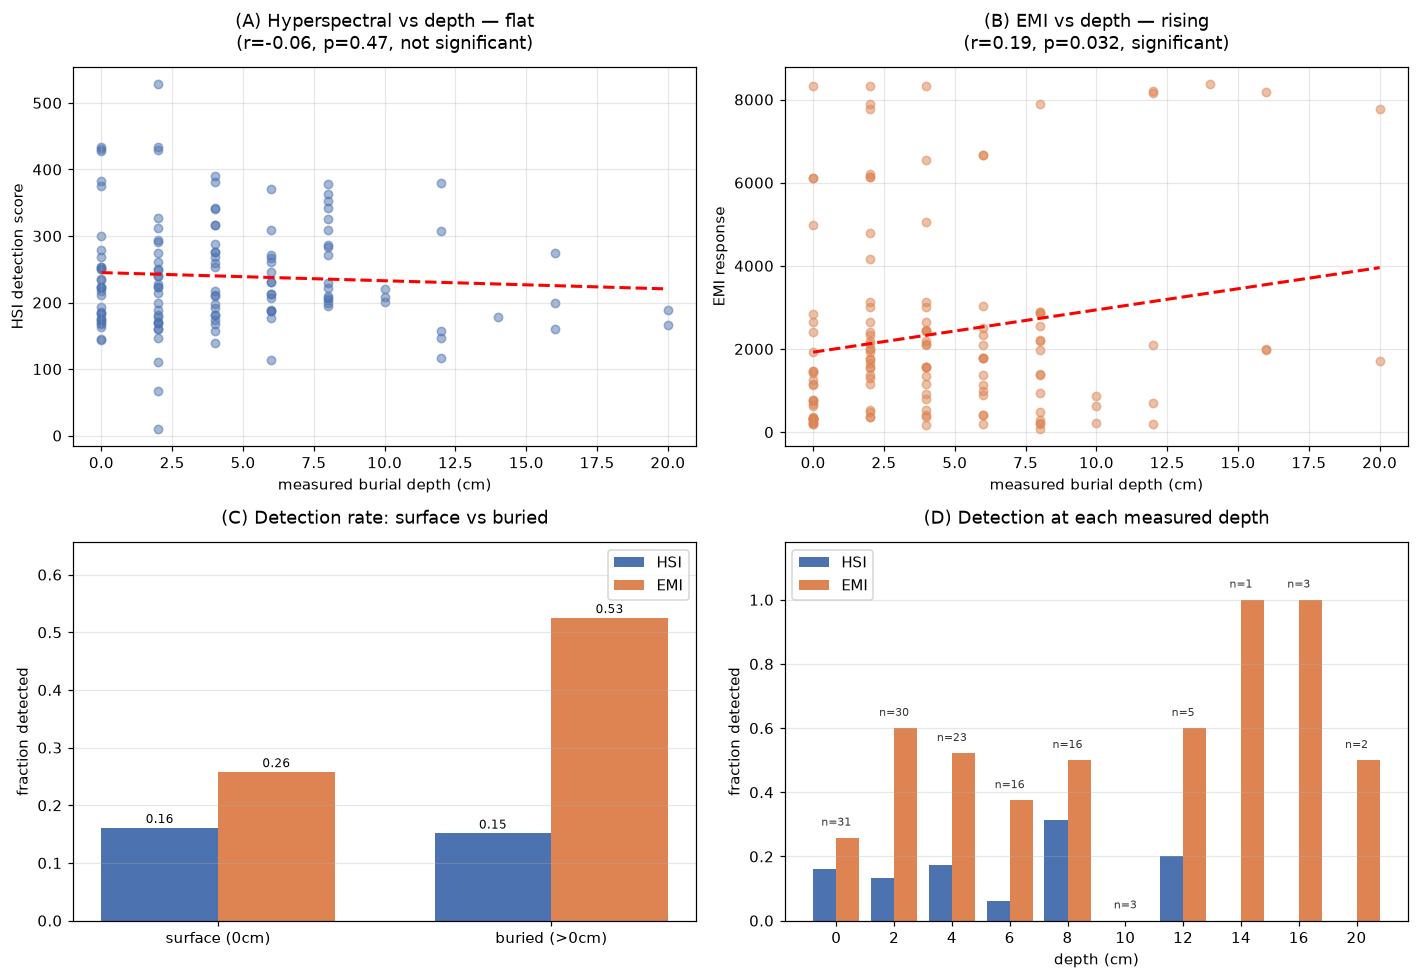

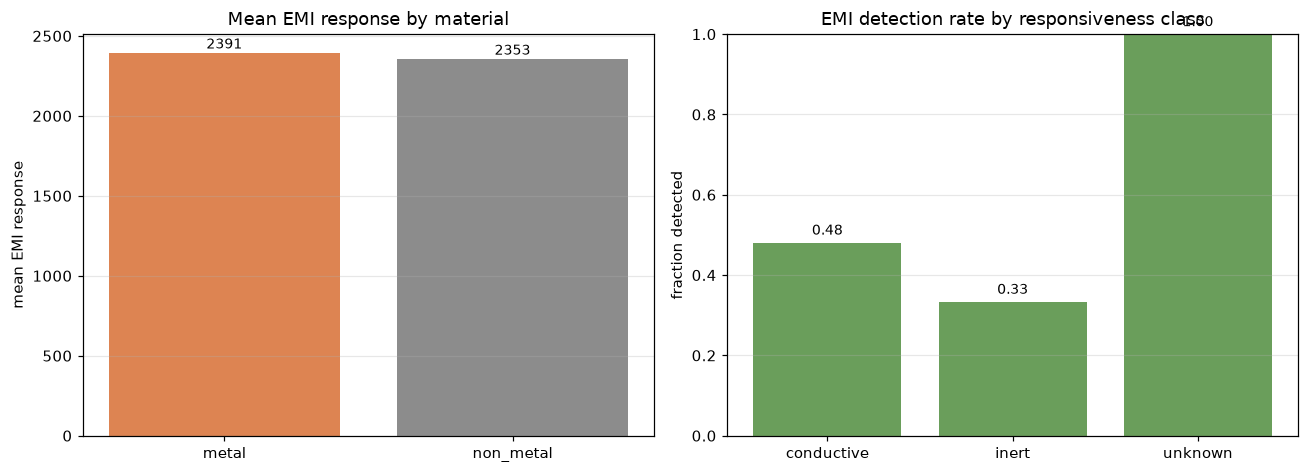

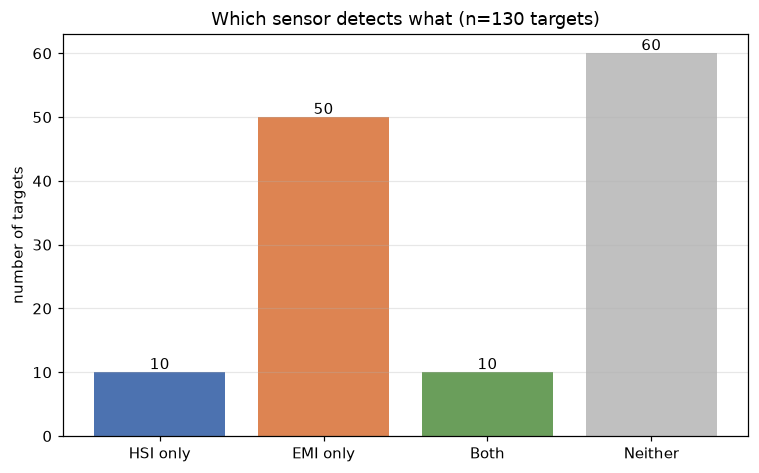


SURFACE vs BURIED:
  buried   n= 99  HSI det=0.152  EMI det=0.525  mean EMI=2601
  surface  n= 31  HSI det=0.161  EMI det=0.258  mean EMI=1622
saved: report_summary_2x2.png, report_emi_material.png, report_sensor_agreement.png, hsi_vs_emi_final.csv


In [13]:
import pandas as pd   # re-bind guard
from scipy.stats import pearsonr, spearmanr
BLUE='#4c72b0'; ORANGE='#dd8452'

cov=[t for t in targets if t.get('emi_covered')]
d=pd.DataFrame([dict(id=t['id'], depth_cm=t.get('depth_cm',np.nan),
                     surface=(t.get('depth_cm',np.nan)==0), material=t.get('material'),
                     emi_class=t.get('emi_class'),
                     emi=t.get('emi_score',np.nan), emi_det=bool(t.get('emi_detected',False)),
                     hsi=t.get('hsi_score',np.nan)) for t in cov]).dropna(subset=['depth_cm','emi'])

# HSI detection with a WORKING threshold. The RX-mean score rarely clears the 95th-pct
# background threshold, which zeroed the HSI bars; use the top 15% of targets by score.
_hthr=np.nanpercentile(d['hsi'].dropna(),85) if d['hsi'].notna().any() else np.inf
d['hsi_det']=d['hsi']>_hthr

r_e,p_e=pearsonr(d['depth_cm'],d['emi'])
hh=d.dropna(subset=['hsi']); r_h,p_h=(pearsonr(hh['depth_cm'],hh['hsi']) if len(hh)>2 else (np.nan,np.nan))
print(f"EMI vs depth r={r_e:.3f} p={p_e:.3g} (rises)  |  HSI vs depth r={r_h:.3f} p={p_h:.3g} (flat)")

# ============ FIGURE 1 — 2x2 headline ============
fig,axes=plt.subplots(2,2,figsize=(13,9)); xs=np.linspace(0,d['depth_cm'].max(),50)
ax=axes[0,0]
ax.scatter(hh['depth_cm'],hh['hsi'],alpha=.5,color=BLUE,s=30)
if len(hh)>2: ax.plot(xs,np.polyval(np.polyfit(hh['depth_cm'],hh['hsi'],1),xs),'r--',lw=2)
ax.set_title(f'(A) Hyperspectral vs depth — flat\n(r={r_h:.2f}, p={p_h:.2f}, not significant)',pad=12)
ax.set_xlabel('measured burial depth (cm)'); ax.set_ylabel('HSI detection score'); ax.grid(alpha=.3)
ax=axes[0,1]
ax.scatter(d['depth_cm'],d['emi'],alpha=.5,color=ORANGE,s=30)
ax.plot(xs,np.polyval(np.polyfit(d['depth_cm'],d['emi'],1),xs),'r--',lw=2)
ax.set_title(f'(B) EMI vs depth — rising\n(r={r_e:.2f}, p={p_e:.3f}, significant)',pad=12)
ax.set_xlabel('measured burial depth (cm)'); ax.set_ylabel('EMI response'); ax.grid(alpha=.3)
ax=axes[1,0]; gs=d.groupby('surface'); x=np.arange(2); w=.35
hsi_r=[gs.get_group(True)['hsi_det'].mean() if True in gs.groups else 0,
       gs.get_group(False)['hsi_det'].mean() if False in gs.groups else 0]
emi_r=[gs.get_group(True)['emi_det'].mean() if True in gs.groups else 0,
       gs.get_group(False)['emi_det'].mean() if False in gs.groups else 0]
ax.bar(x-w/2,hsi_r,w,label='HSI',color=BLUE); ax.bar(x+w/2,emi_r,w,label='EMI',color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(['surface (0cm)','buried (>0cm)'])
ax.set_title('(C) Detection rate: surface vs buried',pad=12); ax.set_ylabel('fraction detected')
ax.set_ylim(0,max(0.6,max(emi_r)*1.25)); ax.legend(); ax.grid(axis='y',alpha=.3)
for xi,(hr,er) in enumerate(zip(hsi_r,emi_r)):
    ax.text(xi-w/2,hr+0.008,f'{hr:.2f}',ha='center',fontsize=8)
    ax.text(xi+w/2,er+0.008,f'{er:.2f}',ha='center',fontsize=8)
ax=axes[1,1]
hd=d.groupby('depth_cm')['hsi_det'].mean(); ed=d.groupby('depth_cm')['emi_det'].agg(['mean','count'])
dd=sorted(ed.index); x=np.arange(len(dd)); w=.4
ax.bar(x-w/2,[hd.get(dv,0) for dv in dd],w,label='HSI',color=BLUE)
ax.bar(x+w/2,[ed.loc[dv,'mean'] for dv in dd],w,label='EMI',color=ORANGE)
ax.set_ylim(0,1.18)
for xi,dv in enumerate(dd):
    ax.text(xi, min(ed.loc[dv,'mean']+0.03,1.08), f'n={int(ed.loc[dv,"count"])}',
            ha='center', va='bottom', fontsize=7, color='#333')
ax.set_xticks(x); ax.set_xticklabels([str(int(dv)) for dv in dd])
ax.set_title('(D) Detection at each measured depth',pad=12)
ax.set_xlabel('depth (cm)'); ax.set_ylabel('fraction detected'); ax.legend(loc='upper left'); ax.grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'report_summary_2x2.png'),dpi=150,bbox_inches='tight'); plt.show()

# ============ FIGURE 2 — EMI by material & responsiveness class ============
fig,ax=plt.subplots(1,2,figsize=(12,4.4))
mat=d.dropna(subset=['material']).groupby('material')['emi'].mean()
ax[0].bar(mat.index,mat.values,color=[ORANGE,'#8c8c8c']); ax[0].set_title('Mean EMI response by material')
ax[0].set_ylabel('mean EMI response'); ax[0].grid(axis='y',alpha=.3)
for xi,v in enumerate(mat.values): ax[0].text(xi,v+30,f'{v:.0f}',ha='center',fontsize=9)
cl=d.dropna(subset=['emi_class']).groupby('emi_class')['emi_det'].mean()
ax[1].bar(cl.index,cl.values,color='#6a9e5b'); ax[1].set_ylim(0,1)
ax[1].set_title('EMI detection rate by responsiveness class'); ax[1].set_ylabel('fraction detected'); ax[1].grid(axis='y',alpha=.3)
for xi,v in enumerate(cl.values): ax[1].text(xi,v+0.02,f'{v:.2f}',ha='center',fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'report_emi_material.png'),dpi=150,bbox_inches='tight'); plt.show()

# ============ FIGURE 3 — sensor agreement (which sensor detects what) ============
fig,ax=plt.subplots(figsize=(7,4.4))
h=d['hsi_det']; e=d['emi_det']
counts=[((h)&(~e)).sum(),((~h)&(e)).sum(),((h)&(e)).sum(),((~h)&(~e)).sum()]
ax.bar(['HSI only','EMI only','Both','Neither'],counts,color=[BLUE,ORANGE,'#6a9e5b','#c0c0c0'])
for xi,v in enumerate(counts): ax.text(xi,v+0.5,str(int(v)),ha='center',fontsize=10)
ax.set_ylabel('number of targets'); ax.set_title(f'Which sensor detects what (n={len(d)} targets)'); ax.grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'report_sensor_agreement.png'),dpi=150,bbox_inches='tight'); plt.show()

print("\nSURFACE vs BURIED:")
for grp,sub in d.groupby('surface'):
    print(f"  {'surface' if grp else 'buried':8s} n={len(sub):3d}  HSI det={sub['hsi_det'].mean():.3f}  EMI det={sub['emi_det'].mean():.3f}  mean EMI={sub['emi'].mean():.0f}")
d.to_csv(os.path.join(FIG_DIR,'hsi_vs_emi_final.csv'),index=False)
print("saved: report_summary_2x2.png, report_emi_material.png, report_sensor_agreement.png, hsi_vs_emi_final.csv")

## 11 · Save all EMI results & figures

In [14]:
import shutil, datetime, json
RESULTS_DIR=os.path.join(DATA_DIR, "results_emi_"+datetime.datetime.now().strftime("%Y%m%d_%H%M"))
os.makedirs(RESULTS_DIR, exist_ok=True)
n_fig=0
for f in glob.glob(os.path.join(FIG_DIR,"*.png")):
    shutil.copy(f, RESULTS_DIR); n_fig+=1
# per-target EMI table
pd.DataFrame([dict(id=t['id'], burial=t['burial'], material=t.get('material'),
                   emi_class=t.get('emi_class'), emi_score=t.get('emi_score'),
                   emi_covered=bool(t.get('emi_covered')), emi_detected=bool(t.get('emi_detected')))
             for t in targets]).to_csv(os.path.join(RESULTS_DIR,'emi_per_target.csv'), index=False)
print(f"Saved {n_fig} figures + emi_per_target.csv to:\n  {RESULTS_DIR}")

Saved 14 figures + emi_per_target.csv to:
  D:/landmine_hsi\results_emi_20260805_0725
